<a href="https://colab.research.google.com/github/ilyademichev1902/test/blob/main/NYC_dangerous_locations_predictions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [498]:
# prompt: attach google drive folder to read the dataset

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [499]:
# prompt: read csv file "cny.csv"

import pandas as pd

df = pd.read_csv('/content/drive/My Drive/datascience/NYPD_Complaint_Data_Current__Year_To_Date_better.csv')

#Exploratory analysis shows that data is missing, NaN and (null) values are present, presumably there are also empty strings

df.head()


<ipython-input-499-7275e5562ee0>:5: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/My Drive/datascience/NYPD_Complaint_Data_Current__Year_To_Date_better.csv')


,CMPLNT_NUM,ADDR_PCT_CD,BORO_NM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,CRM_ATPT_CPTD_CD,HADEVELOPT,HOUSING_PSA,...,TRANSIT_DISTRICT,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Lat_Lon,New Georeferenced Column
0,280510523,14,MANHATTAN,01/11/2024,04:00:00,NaN,(null),COMPLETED,(null),NaN,...,NaN,18-24,BLACK,F,985764.0,213806.0,40.753533,-73.994537,"(40.7535327012632, -73.9945368920152)",POINT (-73.9945368920152 40.7535327012632)
1,286736978,122,STATEN ISLAND,01/01/2015,13:00:00,01/01/2015,15:00:00,COMPLETED,(null),NaN,...,NaN,25-44,UNKNOWN,F,954827.0,148519.0,40.574286,-74.105914,"(40.5742856881925, -74.1059144051212)",POINT (-74.1059144051212 40.5742856881925)
2,289019347,1,MANHATTAN,06/20/2024,16:12:00,06/20/2024,16:13:00,COMPLETED,(null),NaN,...,2.0,25-44,BLACK,F,982466.0,197787.0,40.709556,-74.006435,"(40.70955616028041, -74.00643483276845)",POINT (-74.00643483276845 40.70955616028041)
3,283688417,121,STATEN ISLAND,03/11/2024,10:00:00,03/13/2024,13:20:00,COMPLETED,(null),NaN,...,NaN,25-44,BLACK,F,938414.0,170500.0,40.634542,-74.165142,"(40.634542, -74.165142)",POINT (-74.165142 40.634542)
4,280934552,122,STATEN ISLAND,11/14/2023,12:00:00,11/17/2023,12:00:00,COMPLETED,(null),NaN,...,NaN,65+,WHITE,M,941085.0,135276.0,40.537874,-74.155293,"(40.537874, -74.155293)",POINT (-74.155293 40.537874)


In [500]:
# Uncleaned data in number of rows

print("Rows total:",len(df))


Rows total: 282069


In [501]:
print("Before replacing\nAmount of missed values:\n")
print(df.isna().sum())
#df.head()


Before replacing
Amount of missed values:

CMPLNT_NUM                       0
ADDR_PCT_CD                      0
BORO_NM                          0
CMPLNT_FR_DT                     0
CMPLNT_FR_TM                     0
CMPLNT_TO_DT                 14883
CMPLNT_TO_TM                     0
CRM_ATPT_CPTD_CD                 0
HADEVELOPT                       0
HOUSING_PSA                 264419
JURISDICTION_CODE                0
JURIS_DESC                       0
KY_CD                            0
LAW_CAT_CD                       0
LOC_OF_OCCUR_DESC                0
OFNS_DESC                        0
PARKS_NM                         0
PATROL_BORO                      0
PD_CD                          172
PD_DESC                          0
PREM_TYP_DESC                    0
RPT_DT                           0
STATION_NAME                     0
SUSP_AGE_GROUP                   0
SUSP_RACE                        0
SUSP_SEX                         0
TRANSIT_DISTRICT            269621
VIC_AGE_GROU

In [502]:
#replace missed values with  filler
import numpy as np

filler = pd.NA

df.replace('NaN', filler , inplace=True)
df.replace(np.nan, filler, inplace=True)
df.replace('(null)', filler, inplace=True)


print("After text null and NaN replacing into {}:".format(filler))

print(df.isna().sum())


After text null and NaN replacing into <NA>:
CMPLNT_NUM                       0
ADDR_PCT_CD                      0
BORO_NM                        150
CMPLNT_FR_DT                     0
CMPLNT_FR_TM                     0
CMPLNT_TO_DT                 14883
CMPLNT_TO_TM                 14671
CRM_ATPT_CPTD_CD                 0
HADEVELOPT                  281219
HOUSING_PSA                 264419
JURISDICTION_CODE                0
JURIS_DESC                       0
KY_CD                            0
LAW_CAT_CD                       0
LOC_OF_OCCUR_DESC            60868
OFNS_DESC                        5
PARKS_NM                    280551
PATROL_BORO                      0
PD_CD                          172
PD_DESC                        172
PREM_TYP_DESC                12573
RPT_DT                           0
STATION_NAME                269621
SUSP_AGE_GROUP               31808
SUSP_RACE                    31808
SUSP_SEX                     31808
TRANSIT_DISTRICT            269621
VIC_AGE_GR

In [503]:
# How much data is missing for every column?
threshold = 90
threshold_number = int(len(df) * threshold/100)
print("By threshold of {}%".format(threshold))
print("\n".join([str(num)+":"+str(col)+" missing" if int(col)>threshold_number else str(num)+":"+">"+str(threshold)+"% present" for num,col in enumerate(df.isna().sum())]))


By threshold of 90%
0:>90% present
1:>90% present
2:>90% present
3:>90% present
4:>90% present
5:>90% present
6:>90% present
7:>90% present
8:281219 missing
9:264419 missing
10:>90% present
11:>90% present
12:>90% present
13:>90% present
14:>90% present
15:>90% present
16:280551 missing
17:>90% present
18:>90% present
19:>90% present
20:>90% present
21:>90% present
22:269621 missing
23:>90% present
24:>90% present
25:>90% present
26:269621 missing
27:>90% present
28:>90% present
29:>90% present
30:>90% present
31:>90% present
32:>90% present
33:>90% present
34:>90% present
35:>90% present


In [504]:
print("Elimination of less than {}% of data".format(threshold))
#df = df.drop(df.columns[[8,9,16, 41]], axis=1)
#df = df.drop(df.columns[list(range(20,38))], axis=1)
df = df.drop(df.columns[[8,9,16,22,26]], axis=1)

Elimination of less than 90% of data


In [505]:
#df.dropna(inplace=True)
#df = df.drop('Unnamed: 40', axis=1)
print("After dropping columns with less than {}% data present ,still missing".format(threshold))
print(df.isna().sum())

After dropping columns with less than 90% data present ,still missing
CMPLNT_NUM                      0
ADDR_PCT_CD                     0
BORO_NM                       150
CMPLNT_FR_DT                    0
CMPLNT_FR_TM                    0
CMPLNT_TO_DT                14883
CMPLNT_TO_TM                14671
CRM_ATPT_CPTD_CD                0
JURISDICTION_CODE               0
JURIS_DESC                      0
KY_CD                           0
LAW_CAT_CD                      0
LOC_OF_OCCUR_DESC           60868
OFNS_DESC                       5
PATROL_BORO                     0
PD_CD                         172
PD_DESC                       172
PREM_TYP_DESC               12573
RPT_DT                          0
SUSP_AGE_GROUP              31808
SUSP_RACE                   31808
SUSP_SEX                    31808
VIC_AGE_GROUP                   0
VIC_RACE                       14
VIC_SEX                         0
X_COORD_CD                      4
Y_COORD_CD                      4
Latitude    

In [506]:
label = 'NOT SPECIFIED'
df.fillna(label, inplace=True)
print("All missed cells are replaced by label {}".format(label))
print("<NA> check:\n")
print(df.isna().sum())



All missed cells are replaced by label NOT SPECIFIED
<NA> check:

CMPLNT_NUM                  0
ADDR_PCT_CD                 0
BORO_NM                     0
CMPLNT_FR_DT                0
CMPLNT_FR_TM                0
CMPLNT_TO_DT                0
CMPLNT_TO_TM                0
CRM_ATPT_CPTD_CD            0
JURISDICTION_CODE           0
JURIS_DESC                  0
KY_CD                       0
LAW_CAT_CD                  0
LOC_OF_OCCUR_DESC           0
OFNS_DESC                   0
PATROL_BORO                 0
PD_CD                       0
PD_DESC                     0
PREM_TYP_DESC               0
RPT_DT                      0
SUSP_AGE_GROUP              0
SUSP_RACE                   0
SUSP_SEX                    0
VIC_AGE_GROUP               0
VIC_RACE                    0
VIC_SEX                     0
X_COORD_CD                  0
Y_COORD_CD                  0
Latitude                    0
Longitude                   0
Lat_Lon                     0
New Georeferenced Column    0
dtyp

In [507]:
# prompt: print all columns with a label
print("Columns with missed values:\n")
for column in df.columns:
  if df[column].eq(label).any():
    print(column)


Columns with missed values:

BORO_NM
CMPLNT_TO_DT
CMPLNT_TO_TM
LOC_OF_OCCUR_DESC
OFNS_DESC
PD_CD
PD_DESC
PREM_TYP_DESC
SUSP_AGE_GROUP
SUSP_RACE
SUSP_SEX
VIC_RACE
X_COORD_CD
Y_COORD_CD
Latitude
Longitude
Lat_Lon
New Georeferenced Column


In [508]:

# Drop rows with pandas NaN
before_dropna = df.copy(deep=True)
df.dropna(inplace=True)


In [509]:
print("Data rows left")
print(len(df))

Data rows left
282069


In [510]:
#print amount of unique values for each column
print("Unnique values variety for each column:\n")
print(df.nunique())

Unnique values variety for each column:

CMPLNT_NUM                  282069
ADDR_PCT_CD                     77
BORO_NM                          6
CMPLNT_FR_DT                  1516
CMPLNT_FR_TM                  1440
CMPLNT_TO_DT                  1030
CMPLNT_TO_TM                  1441
CRM_ATPT_CPTD_CD                 2
JURISDICTION_CODE               20
JURIS_DESC                      20
KY_CD                           66
LAW_CAT_CD                       3
LOC_OF_OCCUR_DESC                6
OFNS_DESC                       63
PATROL_BORO                      8
PD_CD                          367
PD_DESC                        357
PREM_TYP_DESC                   83
RPT_DT                         182
SUSP_AGE_GROUP                  19
SUSP_RACE                        8
SUSP_SEX                         4
VIC_AGE_GROUP                   24
VIC_RACE                         8
VIC_SEX                          5
X_COORD_CD                   41317
Y_COORD_CD                   43711
Latitude      

In [511]:
# prompt: drop last 6 columns

df = df.iloc[:, :-6]


In [512]:
# drop columns if they belong to any police internal functioning
# display the head
#
# Drop columns if they exist
for col in ['JURISDICTION_CODE', 'PD_CD','CMPLNT_NUM','KY_CD','ADDR_PCT_CD','PATROL_BORO','JURIS_DESC','RPT_DT']:
  if col in df.columns:
    df = df.drop(col, axis=1)



In [513]:

df.head()


,BORO_NM,CMPLNT_FR_DT,CMPLNT_FR_TM,CMPLNT_TO_DT,CMPLNT_TO_TM,CRM_ATPT_CPTD_CD,LAW_CAT_CD,LOC_OF_OCCUR_DESC,OFNS_DESC,PD_DESC,PREM_TYP_DESC,SUSP_AGE_GROUP,SUSP_RACE,SUSP_SEX,VIC_AGE_GROUP,VIC_RACE,VIC_SEX
0,MANHATTAN,01/11/2024,04:00:00,NOT SPECIFIED,NOT SPECIFIED,COMPLETED,FELONY,INSIDE,RAPE,RAPE 1,HOTEL/MOTEL,18-24,BLACK,U,18-24,BLACK,F
1,STATEN ISLAND,01/01/2015,13:00:00,01/01/2015,15:00:00,COMPLETED,MISDEMEANOR,INSIDE,SEX CRIMES,"SEXUAL ABUSE 3,2",RESIDENCE-HOUSE,25-44,UNKNOWN,M,25-44,UNKNOWN,F
2,MANHATTAN,06/20/2024,16:12:00,06/20/2024,16:13:00,COMPLETED,VIOLATION,NOT SPECIFIED,HARRASSMENT 2,"HARASSMENT,SUBD 1,CIVILIAN",TRANSIT - NYC SUBWAY,45-64,BLACK,M,25-44,BLACK,F
3,STATEN ISLAND,03/11/2024,10:00:00,03/13/2024,13:20:00,COMPLETED,MISDEMEANOR,FRONT OF,PETIT LARCENY,"LARCENY,PETIT FROM OPEN AREAS,",MAILBOX OUTSIDE,NOT SPECIFIED,NOT SPECIFIED,NOT SPECIFIED,25-44,BLACK,F
4,STATEN ISLAND,11/14/2023,12:00:00,11/17/2023,12:00:00,COMPLETED,FELONY,INSIDE,GRAND LARCENY,"LARCENY,GRAND BY ACQUIRING LOST CREDIT CARD",RESIDENCE-HOUSE,NOT SPECIFIED,NOT SPECIFIED,NOT SPECIFIED,65+,WHITE,M


In [514]:
# prompt: number of unique values for each column , display unique values if amount is less than 5
categorical = {}
for col in df.columns:
  unique_vals = df[col].unique()
  num_unique = len(unique_vals)
  #print(f"Column '{col}': {num_unique} unique values")
  if num_unique <= 5:
    categorical[col] = unique_vals
    #print(f"{col}:15: {unique_vals}")


In [515]:
# prompt:  print a dictionary categorical in a  table , each column with increasing number of values

import pandas as pd

# Create a DataFrame from the dictionary
df_categorical = pd.DataFrame.from_dict(categorical, orient='index').transpose()

# Sort columns by the number of unique values
df_categorical = df_categorical.reindex(sorted(df_categorical.columns, key=lambda col: df_categorical[col].nunique()), axis=1)

# Display the DataFrame as a table
print("Unique values for columns with less than 5 variety")
display(df_categorical)


Unique values for columns with less than 5 variety


,CRM_ATPT_CPTD_CD,LAW_CAT_CD,SUSP_SEX,VIC_SEX
0,COMPLETED,FELONY,U,F
1,ATTEMPTED,MISDEMEANOR,M,M
2,None,VIOLATION,NOT SPECIFIED,D
3,None,None,F,L
4,None,None,None,E


In [516]:

# prompt: drop features from df by names from list [CMPLNT_FR_DT ,	CMPLNT_FR_TM 	,CMPLNT_TO_DT 	,CMPLNT_TO_TM 	,CRM_ATPT_CPTD_CD 	]

features_to_drop = [  'CMPLNT_TO_DT', 'CMPLNT_TO_TM']

for feature in features_to_drop:
  if feature in df.columns:
    df = df.drop(feature, axis=1)
print("Removal of time variables (stage 1):\n")
df.head()

Removal of time variables (stage 1):



,BORO_NM,CMPLNT_FR_DT,CMPLNT_FR_TM,CRM_ATPT_CPTD_CD,LAW_CAT_CD,LOC_OF_OCCUR_DESC,OFNS_DESC,PD_DESC,PREM_TYP_DESC,SUSP_AGE_GROUP,SUSP_RACE,SUSP_SEX,VIC_AGE_GROUP,VIC_RACE,VIC_SEX
0,MANHATTAN,01/11/2024,04:00:00,COMPLETED,FELONY,INSIDE,RAPE,RAPE 1,HOTEL/MOTEL,18-24,BLACK,U,18-24,BLACK,F
1,STATEN ISLAND,01/01/2015,13:00:00,COMPLETED,MISDEMEANOR,INSIDE,SEX CRIMES,"SEXUAL ABUSE 3,2",RESIDENCE-HOUSE,25-44,UNKNOWN,M,25-44,UNKNOWN,F
2,MANHATTAN,06/20/2024,16:12:00,COMPLETED,VIOLATION,NOT SPECIFIED,HARRASSMENT 2,"HARASSMENT,SUBD 1,CIVILIAN",TRANSIT - NYC SUBWAY,45-64,BLACK,M,25-44,BLACK,F
3,STATEN ISLAND,03/11/2024,10:00:00,COMPLETED,MISDEMEANOR,FRONT OF,PETIT LARCENY,"LARCENY,PETIT FROM OPEN AREAS,",MAILBOX OUTSIDE,NOT SPECIFIED,NOT SPECIFIED,NOT SPECIFIED,25-44,BLACK,F
4,STATEN ISLAND,11/14/2023,12:00:00,COMPLETED,FELONY,INSIDE,GRAND LARCENY,"LARCENY,GRAND BY ACQUIRING LOST CREDIT CARD",RESIDENCE-HOUSE,NOT SPECIFIED,NOT SPECIFIED,NOT SPECIFIED,65+,WHITE,M


In [517]:
# prompt: extract an hour from CMPLNT_FR_TM and put it inside the cell , drop CMPLNT_FR_TM

# Extract the hour from 'CMPLNT_FR_TM' and create a new column 'Hour'
df['Hour'] = pd.to_datetime(df['CMPLNT_FR_TM'], format='%H:%M:%S').dt.hour

# Drop the original 'CMPLNT_FR_TM' column
df = df.drop('CMPLNT_FR_TM', axis=1)
print("Removal of time variables (stage 2). Get  an hour of the crime into Hour column:\n")
df.head()


Removal of time variables (stage 2). Get  an hour of the crime into Hour column:



,BORO_NM,CMPLNT_FR_DT,CRM_ATPT_CPTD_CD,LAW_CAT_CD,LOC_OF_OCCUR_DESC,OFNS_DESC,PD_DESC,PREM_TYP_DESC,SUSP_AGE_GROUP,SUSP_RACE,SUSP_SEX,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,Hour
0,MANHATTAN,01/11/2024,COMPLETED,FELONY,INSIDE,RAPE,RAPE 1,HOTEL/MOTEL,18-24,BLACK,U,18-24,BLACK,F,4
1,STATEN ISLAND,01/01/2015,COMPLETED,MISDEMEANOR,INSIDE,SEX CRIMES,"SEXUAL ABUSE 3,2",RESIDENCE-HOUSE,25-44,UNKNOWN,M,25-44,UNKNOWN,F,13
2,MANHATTAN,06/20/2024,COMPLETED,VIOLATION,NOT SPECIFIED,HARRASSMENT 2,"HARASSMENT,SUBD 1,CIVILIAN",TRANSIT - NYC SUBWAY,45-64,BLACK,M,25-44,BLACK,F,16
3,STATEN ISLAND,03/11/2024,COMPLETED,MISDEMEANOR,FRONT OF,PETIT LARCENY,"LARCENY,PETIT FROM OPEN AREAS,",MAILBOX OUTSIDE,NOT SPECIFIED,NOT SPECIFIED,NOT SPECIFIED,25-44,BLACK,F,10
4,STATEN ISLAND,11/14/2023,COMPLETED,FELONY,INSIDE,GRAND LARCENY,"LARCENY,GRAND BY ACQUIRING LOST CREDIT CARD",RESIDENCE-HOUSE,NOT SPECIFIED,NOT SPECIFIED,NOT SPECIFIED,65+,WHITE,M,12


In [518]:


if 'CMPLNT_FR_DT' in df.columns:
  df = df.drop('CMPLNT_FR_DT', axis=1)
print("Removal of time variables (stage 3). Only Hour column is left:\n")
df.head()


Removal of time variables (stage 3). Only Hour column is left:



,BORO_NM,CRM_ATPT_CPTD_CD,LAW_CAT_CD,LOC_OF_OCCUR_DESC,OFNS_DESC,PD_DESC,PREM_TYP_DESC,SUSP_AGE_GROUP,SUSP_RACE,SUSP_SEX,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,Hour
0,MANHATTAN,COMPLETED,FELONY,INSIDE,RAPE,RAPE 1,HOTEL/MOTEL,18-24,BLACK,U,18-24,BLACK,F,4
1,STATEN ISLAND,COMPLETED,MISDEMEANOR,INSIDE,SEX CRIMES,"SEXUAL ABUSE 3,2",RESIDENCE-HOUSE,25-44,UNKNOWN,M,25-44,UNKNOWN,F,13
2,MANHATTAN,COMPLETED,VIOLATION,NOT SPECIFIED,HARRASSMENT 2,"HARASSMENT,SUBD 1,CIVILIAN",TRANSIT - NYC SUBWAY,45-64,BLACK,M,25-44,BLACK,F,16
3,STATEN ISLAND,COMPLETED,MISDEMEANOR,FRONT OF,PETIT LARCENY,"LARCENY,PETIT FROM OPEN AREAS,",MAILBOX OUTSIDE,NOT SPECIFIED,NOT SPECIFIED,NOT SPECIFIED,25-44,BLACK,F,10
4,STATEN ISLAND,COMPLETED,FELONY,INSIDE,GRAND LARCENY,"LARCENY,GRAND BY ACQUIRING LOST CREDIT CARD",RESIDENCE-HOUSE,NOT SPECIFIED,NOT SPECIFIED,NOT SPECIFIED,65+,WHITE,M,12


In [519]:
# prompt: drop columns starting from SUSP

cols_to_drop = [col for col in df.columns if col.startswith('SUSP')]
df = df.drop(columns=cols_to_drop)
print("Removal of Suspect data:\n")
df.head()

Removal of Suspect data:



,BORO_NM,CRM_ATPT_CPTD_CD,LAW_CAT_CD,LOC_OF_OCCUR_DESC,OFNS_DESC,PD_DESC,PREM_TYP_DESC,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,Hour
0,MANHATTAN,COMPLETED,FELONY,INSIDE,RAPE,RAPE 1,HOTEL/MOTEL,18-24,BLACK,F,4
1,STATEN ISLAND,COMPLETED,MISDEMEANOR,INSIDE,SEX CRIMES,"SEXUAL ABUSE 3,2",RESIDENCE-HOUSE,25-44,UNKNOWN,F,13
2,MANHATTAN,COMPLETED,VIOLATION,NOT SPECIFIED,HARRASSMENT 2,"HARASSMENT,SUBD 1,CIVILIAN",TRANSIT - NYC SUBWAY,25-44,BLACK,F,16
3,STATEN ISLAND,COMPLETED,MISDEMEANOR,FRONT OF,PETIT LARCENY,"LARCENY,PETIT FROM OPEN AREAS,",MAILBOX OUTSIDE,25-44,BLACK,F,10
4,STATEN ISLAND,COMPLETED,FELONY,INSIDE,GRAND LARCENY,"LARCENY,GRAND BY ACQUIRING LOST CREDIT CARD",RESIDENCE-HOUSE,65+,WHITE,M,12


In [520]:
before_labeling = df.copy(deep=True)


In [521]:
# prompt: based on CMPLNT_FR_DT feature eliminate rows that happened on weekends and holidays of NYC,US . CMPLNT_FR_DT is a text representation of a date

# from datetime import datetime
# import holidays

# us_holidays = holidays.US(years=[2023])  # Assuming your data is from 2023, adjust if needed

# def is_weekend_or_holiday(date_str):
#   try:
#     date = datetime.strptime(date_str, '%m/%d/%Y')
#     return date.weekday() >= 5 or date in us_holidays
#   except ValueError:
#     return False

# # Filter out rows where the date is a weekend or holiday
# df = df[~df['CMPLNT_FR_DT'].apply(is_weekend_or_holiday)]


In [522]:
# prompt: display unique values for each column ,include missing , create a dataframe for better comprehension with small variation of values,extract large variations of values into another separate dataframe . Show both dataframes transposed

# Create a dictionary to store unique values for each column, including missing values
unique_values_dict = {}
for col in df.columns:
  unique_values_dict[col] = df[col].unique()

# Create a DataFrame from the dictionary
df_unique_values = pd.DataFrame.from_dict(unique_values_dict, orient='index').transpose()

# Transpose the DataFrame for better readability
df_unique_values_transposed = df_unique_values.transpose()

# Display the transposed DataFrame
#print("Unique values for each column (including missing values):")
#print(df_unique_values_transposed)


# Create a dictionary to store unique values for each column, including missing values
small_variation_dict = {}
large_variation_dict = {}
for col in df.columns:
  unique_values = df[col].unique()
  num_unique = len(unique_values)
  if num_unique <= 25:
    small_variation_dict[col] = unique_values
  else:
    large_variation_dict[col] = unique_values


# Create DataFrames from the dictionaries
df_small_variation = pd.DataFrame.from_dict(small_variation_dict, orient='index').transpose()
df_large_variation = pd.DataFrame.from_dict(large_variation_dict, orient='index').transpose()


# Transpose the DataFrames for better readability
#df_small_variation_transposed = df_small_variation.transpose()
#df_large_variation_transposed = df_large_variation.transpose()

# Display the transposed DataFrames
print("Variables of small variation  , in range of 1-25: \n")
display(df_small_variation)




Variables of small variation  , in range of 1-25: 



,BORO_NM,CRM_ATPT_CPTD_CD,LAW_CAT_CD,LOC_OF_OCCUR_DESC,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,Hour
0,MANHATTAN,COMPLETED,FELONY,INSIDE,18-24,BLACK,F,4
1,STATEN ISLAND,ATTEMPTED,MISDEMEANOR,NOT SPECIFIED,25-44,UNKNOWN,M,13
2,BRONX,None,VIOLATION,FRONT OF,65+,WHITE,D,16
3,BROOKLYN,None,None,OUTSIDE,45-64,WHITE HISPANIC,L,10
4,NOT SPECIFIED,None,None,REAR OF,UNKNOWN,ASIAN / PACIFIC ISLANDER,E,12
5,QUEENS,None,None,OPPOSITE OF,<18,AMERICAN INDIAN/ALASKAN NATIVE,None,14
6,None,None,None,None,-1,BLACK HISPANIC,None,19
7,None,None,None,None,-973,NOT SPECIFIED,None,22
8,None,None,None,None,-958,None,None,18
9,None,None,None,None,940,None,None,17


In [523]:
print("Variables with large variation, above 25:\n")
display(df_large_variation)

Variables with large variation, above 25:



,OFNS_DESC,PD_DESC,PREM_TYP_DESC
0,RAPE,RAPE 1,HOTEL/MOTEL
1,SEX CRIMES,"SEXUAL ABUSE 3,2",RESIDENCE-HOUSE
2,HARRASSMENT 2,"HARASSMENT,SUBD 1,CIVILIAN",TRANSIT - NYC SUBWAY
3,PETIT LARCENY,"LARCENY,PETIT FROM OPEN AREAS,",MAILBOX OUTSIDE
4,GRAND LARCENY,"LARCENY,GRAND BY ACQUIRING LOST CREDIT CARD",NOT SPECIFIED
...,...,...,...
352,None,"LARCENY,PETIT FROM PARKING MET",None
353,None,SEX CRIMES,None
354,None,DOG STEALING,None
355,None,"LARCENY,PETIT OF BOAT",None


In [524]:
# prompt: print columns with NOT SPECIFIED values
print("Unkonown values are left in:\n")
unknown_values_count = dict()
for column in df.columns:
  if df[column].eq(label).any():
    count = (df[column] == label).sum()
    print(f"Column {column}: {count}")
    unknown_values_count[column] = count


Unkonown values are left in:

Column BORO_NM: 150
Column LOC_OF_OCCUR_DESC: 60868
Column OFNS_DESC: 5
Column PD_DESC: 172
Column PREM_TYP_DESC: 12573
Column VIC_RACE: 14


In [525]:
print("These columns should omit 0 in encoding:\n")
print(set(df.columns)-set(unknown_values_count.keys()))

These columns should omit 0 in encoding:

{'VIC_SEX', 'CRM_ATPT_CPTD_CD', 'Hour', 'VIC_AGE_GROUP', 'LAW_CAT_CD'}


In [526]:
# prompt: check for empty cells

# Check for empty cells in the DataFrame
empty_cells = df.isnull().sum()

# Print the number of empty cells for each column
print("Empty cells in each column:\n")
print(empty_cells)

# Check if there are any empty cells in the entire DataFrame
if df.isnull().values.any():
  print("\nThe DataFrame contains empty cells.")
else:
  print("\nThe DataFrame does not contain any empty cells.")


Empty cells in each column:

BORO_NM              0
CRM_ATPT_CPTD_CD     0
LAW_CAT_CD           0
LOC_OF_OCCUR_DESC    0
OFNS_DESC            0
PD_DESC              0
PREM_TYP_DESC        0
VIC_AGE_GROUP        0
VIC_RACE             0
VIC_SEX              0
Hour                 0
dtype: int64

The DataFrame does not contain any empty cells.


In [527]:
# prompt: eliminate [ OFNS_DESC , PD_DES]

# columns_to_eliminate = ['LOC_OF_OCCUR_DESC' ]#, 'PD_DESC']

# for column in columns_to_eliminate:
#   if column in df.columns:
#     df = df.drop(column, axis=1)

# df.head()


In [528]:
# prompt: show unique values count for each column
print("Variable variety:\n")
for column in df.columns:
  unique_count = df[column].nunique()
  print(f"{column}: {unique_count} ")


Variable variety:

BORO_NM: 6 
CRM_ATPT_CPTD_CD: 2 
LAW_CAT_CD: 3 
LOC_OF_OCCUR_DESC: 6 
OFNS_DESC: 63 
PD_DESC: 357 
PREM_TYP_DESC: 83 
VIC_AGE_GROUP: 24 
VIC_RACE: 8 
VIC_SEX: 5 
Hour: 24 


In [529]:
# prompt: print unique values for SUSP_SEX
print("Explore sex variable:\n")
print(df['VIC_SEX'].unique())


Explore sex variable:

['F' 'M' 'D' 'L' 'E']


In [530]:
#prompt: eliminate PREM_TYP_DESC

# if 'PREM_TYP_DESC' in df.columns:
#   df = df.drop('PREM_TYP_DESC', axis=1)

# df.head()


In [531]:
#case 1 : simplified with less then 5 categories
#before_labeling_case_1 = df.copy(deep=True)
#case 1 : extended with description of agression and property
before_labeling_case_2 = df.copy(deep=True)

In [532]:
# prompt: replace NOT SPECIFIED with AAAAAA in all columns,to make it 0 encoded

label = 'NOT SPECIFIED'
replacement_label = 'AAAAAA'

for column in df.columns:
  df[column] = df[column].replace(label, replacement_label)


In [533]:
# prompt: encode all columns 0 value to 0 label, all other labels start from 1 , don't encode ['LAW_CAT_CD', 'VIC_AGE_GROUP', 'SUSP_AGE_GROUP', 'VIC_SEX', 'SUSP_SEX']
#replace NOT SPECIFIED values in all columns with 0 class
from sklearn.preprocessing import LabelEncoder

# Create a LabelEncoder object
label_encoder = LabelEncoder()

columns_to_encode = [col for col in df.columns if col not in ['LAW_CAT_CD','CRM_ATPT_CPTD_CD', 'VIC_AGE_GROUP', 'SUSP_AGE_GROUP', 'VIC_SEX', 'SUSP_SEX','Hour']]

for column in columns_to_encode:
  # Fit and transform the column
  df[column] = label_encoder.fit_transform(df[column])
  # Replace encoded 0 with 0 label, other labels start from 1



In [534]:
# prompt: count number of 0 in each column
zeros_column_count  = {}
for column in df.columns:
  count = (df[column] == 0).sum()
  print(f"Column {column}: {count}")
  zeros_column_count[column] = count


Column BORO_NM: 150
Column CRM_ATPT_CPTD_CD: 0
Column LAW_CAT_CD: 0
Column LOC_OF_OCCUR_DESC: 60868
Column OFNS_DESC: 5
Column PD_DESC: 172
Column PREM_TYP_DESC: 12573
Column VIC_AGE_GROUP: 0
Column VIC_RACE: 14
Column VIC_SEX: 0
Column Hour: 12029


In [535]:
replaced_correctly = True
for k in unknown_values_count.keys():
  if zeros_column_count[k]!=unknown_values_count[k]:
    replaced_correctly = False
    break
if replaced_correctly :
  print("{} labels are all properly encoded to 0".format(label))
else :
  print("ERROR:{} labels are not all properly encoded to 0".format(label))


NOT SPECIFIED labels are all properly encoded to 0


In [536]:
print("Encoded columns, ordinal variables and exceptions are left:\n")
df.head()


Encoded columns, ordinal variables and exceptions are left:



,BORO_NM,CRM_ATPT_CPTD_CD,LAW_CAT_CD,LOC_OF_OCCUR_DESC,OFNS_DESC,PD_DESC,PREM_TYP_DESC,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,Hour
0,3,COMPLETED,FELONY,2,55,267,37,18-24,3,F,4
1,5,COMPLETED,MISDEMEANOR,2,57,316,63,25-44,5,F,13
2,3,COMPLETED,VIOLATION,0,28,123,78,25-44,3,F,16
3,5,COMPLETED,MISDEMEANOR,1,51,198,42,25-44,3,F,10
4,5,COMPLETED,FELONY,2,26,145,63,65+,6,M,12


In [537]:
# prompt: manually encode LAW_CAT_CD , VIC_AGE_GROUP

# Manually encode 'LAW_CAT_CD'
law_cat_mapping = {
    'FELONY': 3,
    'MISDEMEANOR': 2,
    'VIOLATION': 1,
    label : 0
}
df['LAW_CAT_CD'] = df['LAW_CAT_CD'].map(law_cat_mapping)

# Manually encode 'VIC_AGE_GROUP'
vic_age_mapping = {
    '<18': 1,
    '18-24': 2,
    '25-44': 3,
    '45-64': 4,
    '65+': 5,
    label : 0
}

susp_sex_mapping = {
    'U': 0,
    'M': 1,
    'F': 2,
    label : 0
}

vic_sex_mapping = {
    'M':1,
    'F':2,
    'D':3,
    'E':4,
    'L':5,
    label : 0

}

comp_atmp = {
    'COMPLETED':1,
    'ATTEMPTED':2,
    label : 0

}

df['VIC_AGE_GROUP'] = df['VIC_AGE_GROUP'].map(vic_age_mapping)
#df['SUSP_AGE_GROUP'] = df['SUSP_AGE_GROUP'].map(vic_age_mapping)
df['VIC_SEX'] = df['VIC_SEX'].map(vic_sex_mapping)
df['CRM_ATPT_CPTD_CD'] = df['CRM_ATPT_CPTD_CD'].map(comp_atmp)

#df['SUSP_SEX'] = df['SUSP_SEX'].map(susp_sex_mapping)
print("Ordinal variables are manually encoded:\n")
df.head()


Ordinal variables are manually encoded:



,BORO_NM,CRM_ATPT_CPTD_CD,LAW_CAT_CD,LOC_OF_OCCUR_DESC,OFNS_DESC,PD_DESC,PREM_TYP_DESC,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,Hour
0,3,1,3,2,55,267,37,2.0,3,2,4
1,5,1,2,2,57,316,63,3.0,5,2,13
2,3,1,1,0,28,123,78,3.0,3,2,16
3,5,1,2,1,51,198,42,3.0,3,2,10
4,5,1,3,2,26,145,63,5.0,6,1,12


In [538]:
# prompt: drop all UNKNOWN values from VIC_AGE_GROUP,  try to convert each row into integer, drop the row if  the number value is  negative or above 900, otherwise leave intact

# Drop rows where 'VIC_AGE_GROUP' is 'UNKNOWN'
#df = df[df['VIC_AGE_GROUP'] != 'UNKNOWN']
#df = df[df['SUSP_AGE_GROUP'] != 'UNKNOWN']
print("Convert not specified or erroneous values of VIC_AGE to 0:\n")
# Attempt to convert 'VIC_AGE_GROUP' to integer and handle errors
def convert_to_int_or_set_unknown(value):
  try:
    int_value = int(value)
    if 0 <= int_value <= 5:
      return int_value # correct value
    # else:
    #   return None  # Replace with None or another appropriate value
  except (ValueError, TypeError):
    return 0  # Replace with 0 for all missed and unknown

df['VIC_AGE_GROUP'] = df['VIC_AGE_GROUP'].apply(convert_to_int_or_set_unknown)
#df['SUSP_AGE_GROUP'] = df['SUSP_AGE_GROUP'].apply(convert_to_int_or_set_unknown)
# Drop rows with None values in 'VIC_AGE_GROUP' (resulting from filtering)
#df.dropna(subset=['VIC_AGE_GROUP'], inplace=True)
#df.dropna(subset=['SUSP_AGE_GROUP'], inplace=True)
# Convert 'VIC_AGE_GROUP' to integer type
df['VIC_AGE_GROUP'] = df['VIC_AGE_GROUP'].astype(int)
#df['SUSP_AGE_GROUP'] = df['SUSP_AGE_GROUP'].astype(int)

df.head()


Convert not specified or erroneous values of VIC_AGE to 0:



,BORO_NM,CRM_ATPT_CPTD_CD,LAW_CAT_CD,LOC_OF_OCCUR_DESC,OFNS_DESC,PD_DESC,PREM_TYP_DESC,VIC_AGE_GROUP,VIC_RACE,VIC_SEX,Hour
0,3,1,3,2,55,267,37,2,3,2,4
1,5,1,2,2,57,316,63,3,5,2,13
2,3,1,1,0,28,123,78,3,3,2,16
3,5,1,2,1,51,198,42,3,3,2,10
4,5,1,3,2,26,145,63,5,6,1,12


In [539]:
# prompt: show values distribution for VIC_AGE_GROUP with missed and NaN values

# Assuming 'before_dropna' DataFrame still contains the original data with missing values
print(df['VIC_AGE_GROUP'].value_counts(dropna=False))
#print(df['SUSP_AGE_GROUP'].value_counts(dropna=False))

VIC_AGE_GROUP
3    95280
0    90672
4    48600
2    22094
5    13646
1    11777
Name: count, dtype: int64


In [540]:
# prompt:   encode OFNS_DESC with labelencoder specify CRM_ATPT_CPTD_CD as a target variable and others as predictors

# Apply LabelEncoder to 'OFNS_DESC'
# simple_offense_description = df.drop('PD_DESC',axis=1)
# extended_offense_description = df.drop('OFNS_DESC',axis=1)
# without_offense_description = df.drop(['PD_DESC','OFNS_DESC'],axis=1)
# #label_encoder = LabelEncoder()
# #simple_offense_description['OFNS_DESC'] = label_encoder.fit_transform(simple_offense_description['OFNS_DESC'])

# without_offense_description.head()

In [541]:
# prompt: drop VIC_RACE

# Assuming 'df' is your DataFrame
# if 'VIC_RACE' in df.columns:
#   df = df.drop('VIC_RACE', axis=1)
# df.head()

In [542]:
# prompt: encode Hour manually starting from 1 to 24

hour_mapping = {hour: hour_index for hour_index, hour in enumerate(range(24), start=1)}
print(hour_mapping)

df['Hour'] = df['Hour'].map(hour_mapping)


{0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24}


**The variety of columns on 2D plots:**

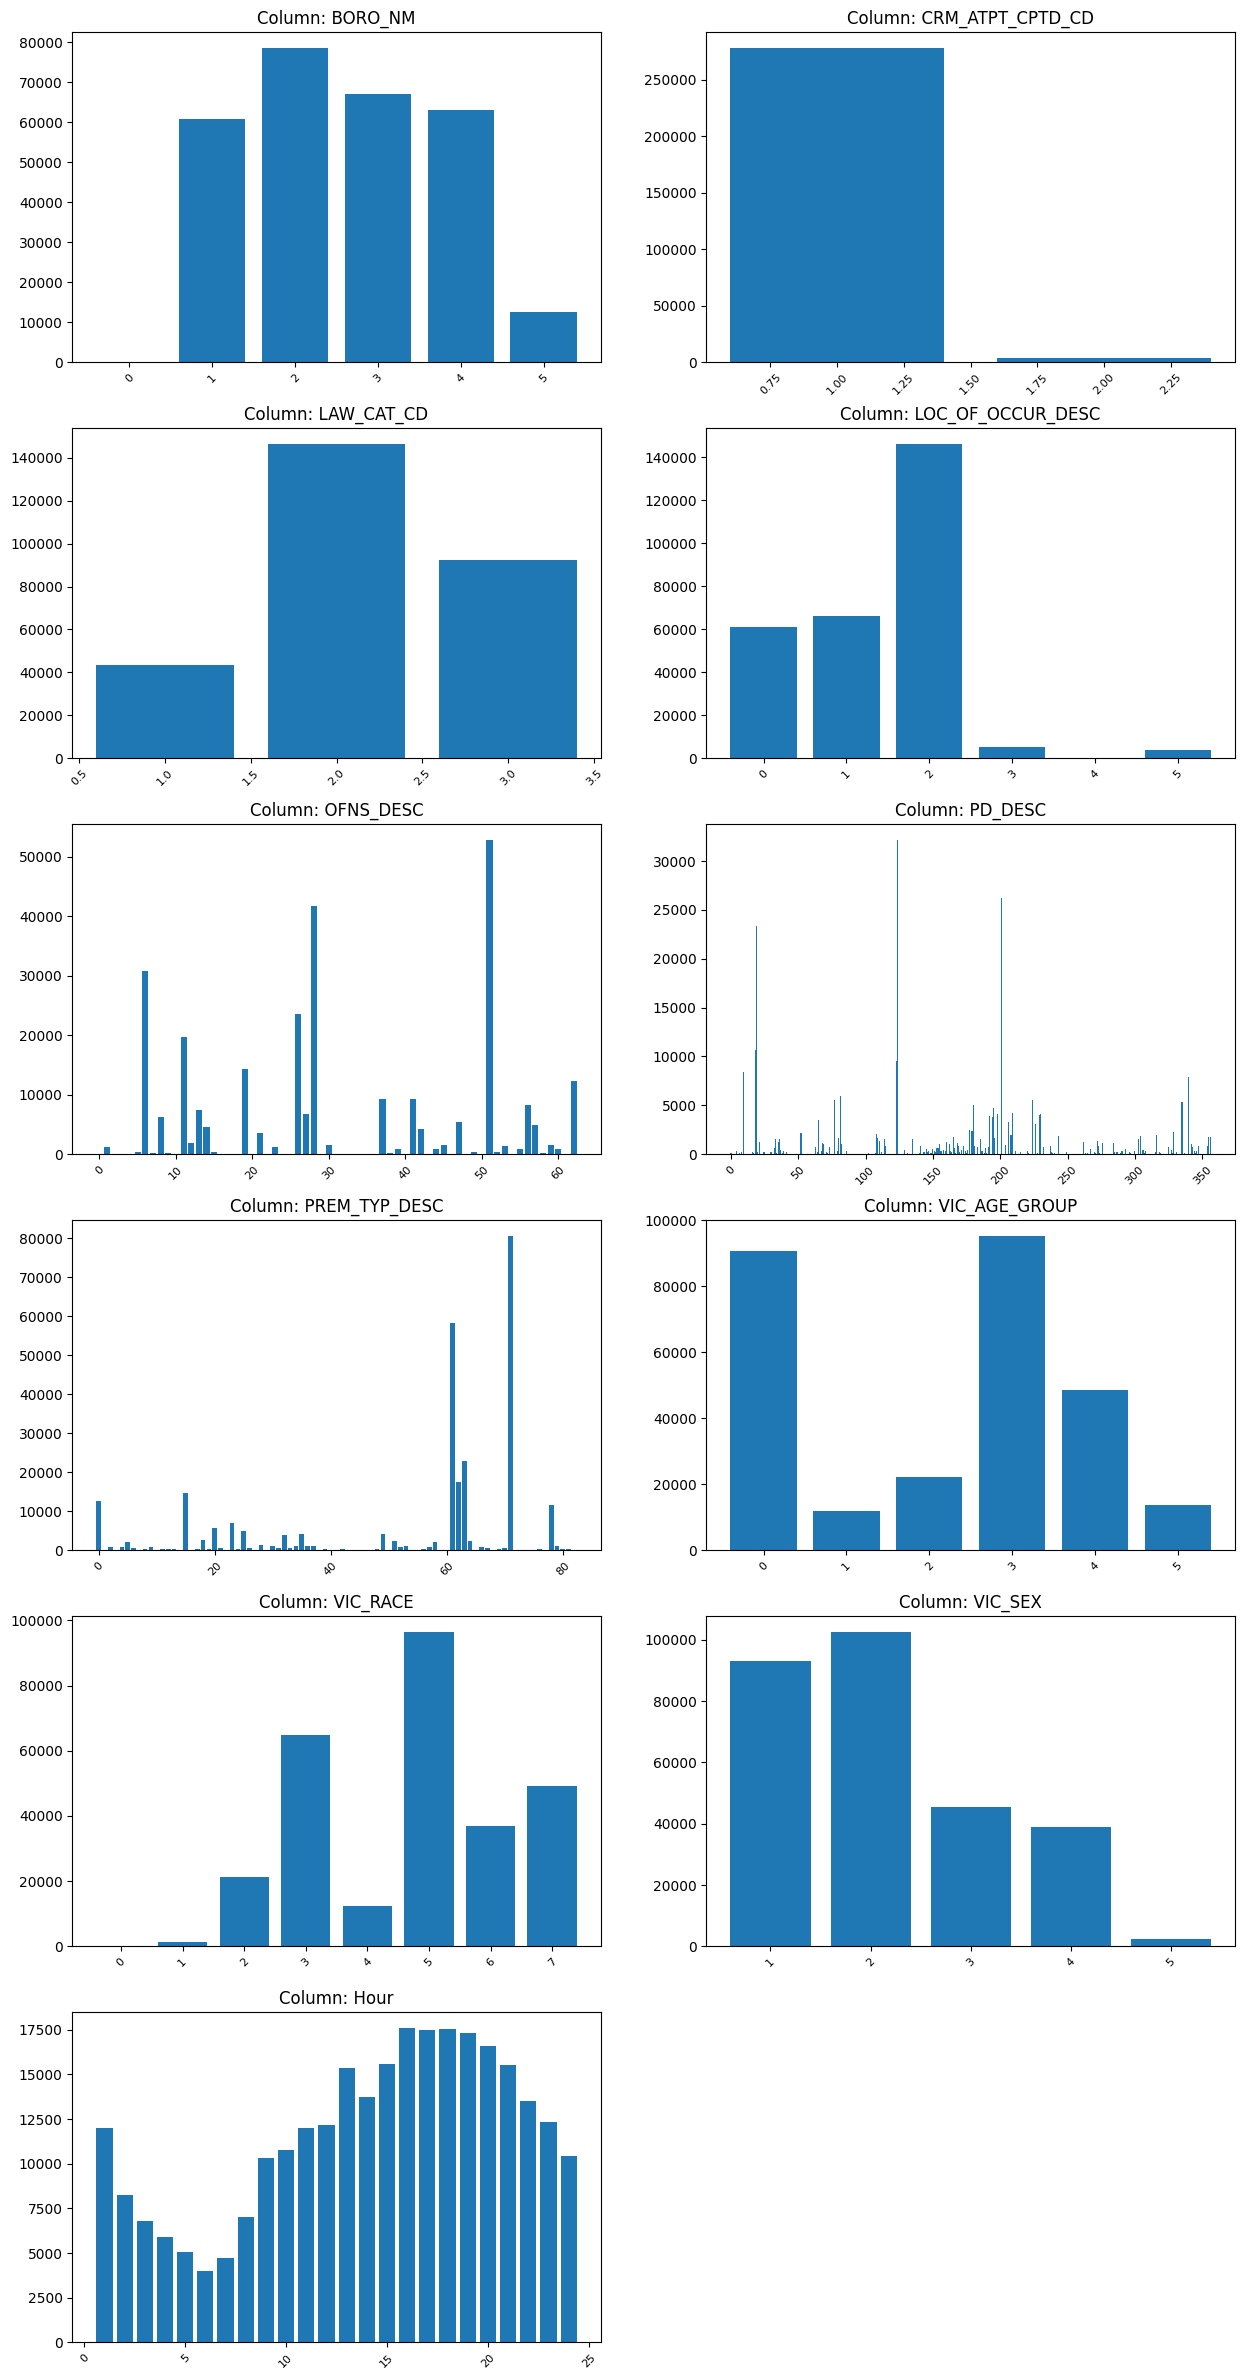

In [543]:
# prompt:  Count amount of each unique value for each column in df and show the distributions graphically as small plots close to each other 3 plots on each line

import matplotlib.pyplot as plt

# Calculate the number of unique values for each column
unique_counts = df.nunique()

# Create a figure and axes for the subplots
num_cols = 2
num_rows = (len(unique_counts) + num_cols - 1) // num_cols
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))

# Iterate through the columns and create a plot for each
for i, (column, count) in enumerate(unique_counts.items()):
    row = i // num_cols
    col = i % num_cols

    # Create a bar plot for the unique value counts
    value_counts = df[column].value_counts()
    axes[row, col].bar(value_counts.index, value_counts.values)
    axes[row, col].set_title(f"Column: {column}")
    axes[row, col].tick_params(axis='x', rotation=45, labelsize=8)

    # Remove extra subplots if necessary
    if i >= len(unique_counts) - 1:
        for j in range(i + 1, num_rows * num_cols):
            row_extra = j // num_cols
            col_extra = j % num_cols
            fig.delaxes(axes[row_extra, col_extra])

# Adjust the layout and display the plots
#plt.tight_layout()
plt.show()


In [544]:
print("For VIC_SEX only Male and Female categories are left\n")
# prompt: drop from VIC_SEX and SUSP_SEX rows with values except 1 or 2

# Filter the DataFrame to keep only rows where 'VIC_SEX' is 1 or 2
df = df[(df['VIC_SEX'] == 1) | (df['VIC_SEX'] == 2)]

# Filter the DataFrame to keep only rows where 'SUSP_SEX' is 1 or 2
#df = df[(df['SUSP_SEX'] == 1) | (df['SUSP_SEX'] == 2)]


For VIC_SEX only Male and Female categories are left



In [545]:
# target_variable = 'VIC_SEX'
# #X = pd.DataFrame()
# #y = pd.DataFrame()
# indexes_to_keep = pd.Index([])
# # Calculate value counts for each column, exclude less than 5  for chi2
# for col in list(df.columns):
#   value_counts = df[col].value_counts()
#   # Filter out values with counts less than 5
#   print(value_counts[value_counts > 5].index)
#   #indexes_to_keep.union( value_counts[value_counts > 5].index)
#   # Create a new DataFrame 'X' excluding rows where 'PREM_TYP_DESC' has counts less than 5

# #X = df[df.isin(indexes_to_keep)].drop([target_variable], axis=1)
# #y = df[df.isin(indexes_to_keep)][target_variable]

# print(indexes_to_keep)

In [546]:
# prompt: determine classes of unique values for each df column leave into filtered_df with less than 7.
variety_threshold = 100
filtered_df = pd.DataFrame()
for column in df.columns:
  unique_values = df[column].unique()
  if len(unique_values) <= variety_threshold:
    filtered_df[column] = df[column]




In [547]:
# prompt: pretty print columns of filtered_df

print("Columns of filtered_df with less or equal to {} variety:\n".format(variety_threshold))
for column in filtered_df.columns:
  print(column)


Columns of filtered_df with less or equal to 100 variety:

BORO_NM
CRM_ATPT_CPTD_CD
LAW_CAT_CD
LOC_OF_OCCUR_DESC
OFNS_DESC
PREM_TYP_DESC
VIC_AGE_GROUP
VIC_RACE
VIC_SEX
Hour


In [548]:
# Count amount of each unique value for each column in X
for col in filtered_df.columns:
  unique_values_count = filtered_df[col].value_counts()
  print(f"Unique values count for column '{col}':\n{unique_values_count}\n")


Unique values count for column 'BORO_NM':
BORO_NM
2    55561
1    45544
4    45314
3    40137
5     8935
0      123
Name: count, dtype: int64

Unique values count for column 'CRM_ATPT_CPTD_CD':
CRM_ATPT_CPTD_CD
1    192533
2      3081
Name: count, dtype: int64

Unique values count for column 'LAW_CAT_CD':
LAW_CAT_CD
2    87056
3    66729
1    41829
Name: count, dtype: int64

Unique values count for column 'LOC_OF_OCCUR_DESC':
LOC_OF_OCCUR_DESC
2    103834
1     53852
0     31050
3      3801
5      2974
4       103
Name: count, dtype: int64

Unique values count for column 'OFNS_DESC':
OFNS_DESC
28    41644
6     30736
51    25021
26    19488
11    13618
19    13240
41     8923
37     7430
56     7173
27     6405
57     4634
62     3682
8      3205
42     1780
59     1442
53      929
23      837
55      813
44      683
14      592
12      569
60      412
21      292
52      292
1       266
47      259
5       192
30      183
38      172
13      161
49      149
45       86
34       62
32 

In [549]:
# Specify target variable

target_variable = 'VIC_SEX'
#test_size = 0.3

#from sklearn.model_selection import train_test_split

X = filtered_df.drop([target_variable], axis=1).copy(deep=True)  # Predictors
y = filtered_df[target_variable].copy(deep=True)  # Target variable

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)

#X = X_train.copy(deep=True)
#y = y_train.copy(deep=True)


In [550]:
#X.head()

In [551]:
# prompt: count amount of each unique value for y

unique_values_count = y.value_counts()
print("Balance of a target variable {}".format(target_variable))
print(unique_values_count)


Balance of a target variable VIC_SEX
VIC_SEX
2    102510
1     93104
Name: count, dtype: int64


In [ ]:
# prompt: plot a histogram of LAW_CAT_CD , under each bin display the ratio of the whole ,display bins with proper width

# import matplotlib.pyplot as plt

# # Calculate the value counts for 'LAW_CAT_CD'
# value_counts = df['LAW_CAT_CD'].value_counts(normalize=True)

# # Create a histogram with custom bin width
# plt.hist(df['LAW_CAT_CD'], bins=range(min(df['LAW_CAT_CD']), max(df['LAW_CAT_CD']) + 2), edgecolor='black' ,color='red',rwidth=0.8)

# # Add text labels for each bin with the ratio
# for i in range(min(df['LAW_CAT_CD']), max(df['LAW_CAT_CD']) + 1):
#     count = df['LAW_CAT_CD'][df['LAW_CAT_CD'] == i].count()
#     ratio = count / len(df)
#     plt.text(i, count + 0.1, f'{ratio:.2f}', ha='center')

# # Customize the plot
# plt.xlabel('LAW_CAT_CD')
# plt.ylabel('Frequency')
# plt.title('Histogram of LAW_CAT_CD')
# plt.xticks([1, 2,3], ['V', 'M','F'])
# plt.show()


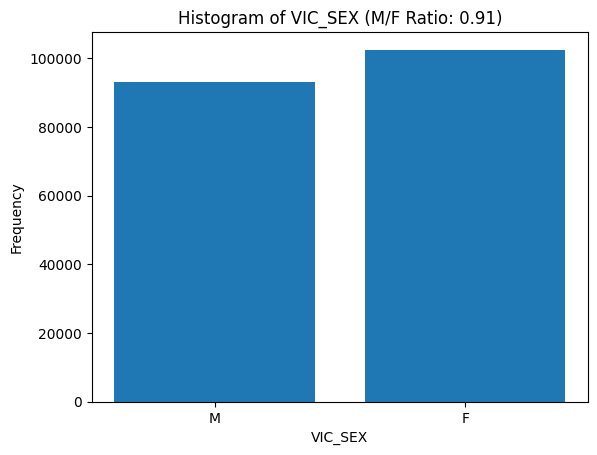

In [557]:
#prompt: plot a histogram of a y dataframe, susbscribe 1 as M , 2 as F. Calculate the ratio of one to another and display it above the histogram

import matplotlib.pyplot as plt

# Calculate value counts for y
value_counts = y.value_counts()

# Create a dictionary to map values to labels
#labels = {1: 'M', 2: 'F'}
labels = {1: 'M', 2: 'F'}

# Rename the index of value_counts using the labels dictionary
value_counts.rename(index=labels, inplace=True)


# Calculate the ratio of M to F
ratio_M_to_F = value_counts.get('M', 0) / value_counts.get('F', 1)

# Create the histogram
plt.hist(y, bins=[0.5, 1.5, 2.5], rwidth=0.8)
plt.xlabel('VIC_SEX')
plt.ylabel('Frequency')
plt.title('Histogram of VIC_SEX (M/F Ratio: {:.2f})'.format(ratio_M_to_F))

# Customize the x-axis ticks
plt.xticks([1, 2], ['M', 'F'])
plt.show()


In [558]:
# prompt: drop PD_DESC and LAW_CAT_CD

if 'PD_DESC' in X.columns:
  X = X.drop('PD_DESC', axis=1)

# if 'LAW_CAT_CD' in X.columns:
#   X = X.drop('LAW_CAT_CD', axis=1)

X.head()


,BORO_NM,CRM_ATPT_CPTD_CD,LAW_CAT_CD,LOC_OF_OCCUR_DESC,OFNS_DESC,PREM_TYP_DESC,VIC_AGE_GROUP,VIC_RACE,Hour
0,3,1,3,2,55,37,2,3,5
1,5,1,2,2,57,63,3,5,14
2,3,1,1,0,28,78,3,3,17
3,5,1,2,1,51,42,3,3,11
4,5,1,3,2,26,63,5,6,13


**Feature Selection procedures**

In [559]:
# prompt: use feature selection based on SelectKBest , print out selected feature names

from sklearn.feature_selection import SelectKBest, chi2

# Assuming X and y are defined as in your previous code
selected_features_chi2 = []
# Select the top 10 features based on given statistic
for k in range(1,len(X.columns),1):
  selector = SelectKBest(chi2, k=k)
  X_kbest = selector.fit_transform(X, y)
  selected_features_indices = selector.get_support(indices=True)
  print("For {} features chi2 criteria:".format(k))
  # Get the names of the selected features
  selected_features = X.columns[selected_features_indices]

  print("Selected features:", list(selected_features))
  print("Eliminated features:", list(set(X.columns)-set(selected_features)))
  # Print the shape of the original and selected data
  #print("Original data shape:", X.shape)
  #print("Selected data shape:", X_kbest.shape)
  selected_features_chi2.append(selected_features)
  print("\n")
  # Get the indices of the selected features


For 1 features chi2 criteria:
Selected features: ['LOC_OF_OCCUR_DESC']
Eliminated features: ['VIC_RACE', 'BORO_NM', 'CRM_ATPT_CPTD_CD', 'PREM_TYP_DESC', 'Hour', 'OFNS_DESC', 'VIC_AGE_GROUP', 'LAW_CAT_CD']


For 2 features chi2 criteria:
Selected features: ['LAW_CAT_CD', 'LOC_OF_OCCUR_DESC']
Eliminated features: ['VIC_RACE', 'CRM_ATPT_CPTD_CD', 'PREM_TYP_DESC', 'Hour', 'OFNS_DESC', 'VIC_AGE_GROUP', 'BORO_NM']


For 3 features chi2 criteria:
Selected features: ['LAW_CAT_CD', 'LOC_OF_OCCUR_DESC', 'PREM_TYP_DESC']
Eliminated features: ['VIC_RACE', 'CRM_ATPT_CPTD_CD', 'Hour', 'OFNS_DESC', 'VIC_AGE_GROUP', 'BORO_NM']


For 4 features chi2 criteria:
Selected features: ['BORO_NM', 'LAW_CAT_CD', 'LOC_OF_OCCUR_DESC', 'PREM_TYP_DESC']
Eliminated features: ['VIC_RACE', 'CRM_ATPT_CPTD_CD', 'Hour', 'OFNS_DESC', 'VIC_AGE_GROUP']


For 5 features chi2 criteria:
Selected features: ['BORO_NM', 'LAW_CAT_CD', 'LOC_OF_OCCUR_DESC', 'OFNS_DESC', 'PREM_TYP_DESC']
Eliminated features: ['VIC_RACE', 'Hour', 'CRM

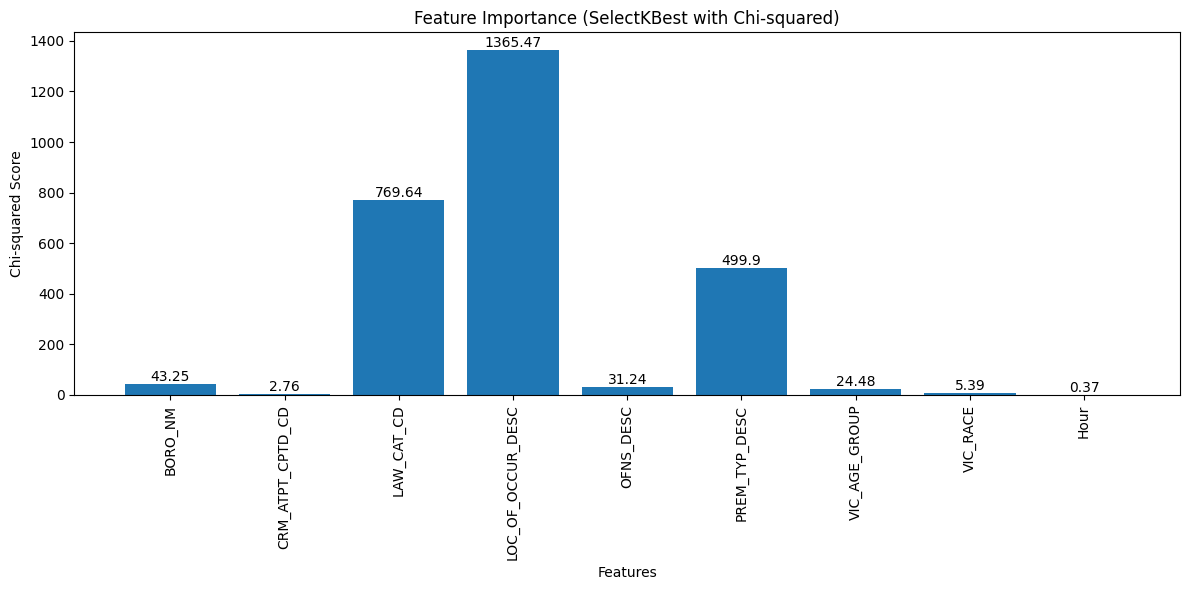

In [560]:
# prompt: create a plot of feature importance from SelectKBest with chi2 for all features , display score on the top of each bar

import matplotlib.pyplot as plt

# Assuming you have already performed SelectKBest with chi2 and have 'selector' defined
# Also assuming you have 'X' defined as your feature DataFrame

selector = SelectKBest(chi2, k='all')  # Select all features
X_kbest = selector.fit_transform(X, y)
scores = selector.scores_

# Create a bar plot of feature importances
plt.figure(figsize=(12, 6))
plt.bar(X.columns, scores)
plt.xlabel("Features")
plt.ylabel("Chi-squared Score")
plt.title("Feature Importance (SelectKBest with Chi-squared)")
plt.xticks(rotation=90)

# Add score value on top of each bar
for i, score in enumerate(scores):
  plt.text(i, score, str(round(score, 2)), ha='center', va='bottom')

plt.tight_layout()
plt.show()


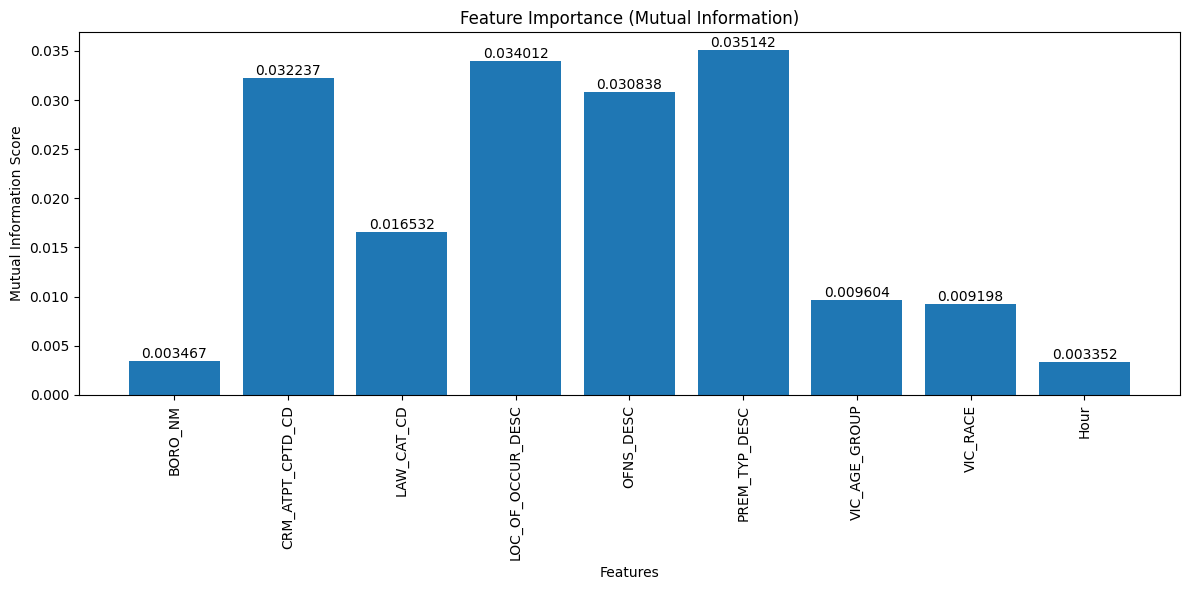

In [562]:
# prompt: plot feature importance based on mutual information

from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

# Calculate mutual information scores
mi_scores = mutual_info_classif(X, y)

# Create a bar plot of feature importances
plt.figure(figsize=(12, 6))
plt.bar(X.columns, mi_scores)
plt.xlabel("Features")
plt.ylabel("Mutual Information Score")
plt.title("Feature Importance (Mutual Information)")
plt.xticks(rotation=90)

# Add score value on top of each bar
for i, score in enumerate(mi_scores):
  plt.text(i, score, str(round(score, 6)), ha='center', va='bottom')

plt.tight_layout()
plt.show()


In [464]:
#X = filtered_df.drop([target_variable], axis=1).copy(deep=True)  # Predictors
#y = filtered_df[target_variable].copy(deep=True)  # Target variable

# Chose  most significant variables based on chi2 with detailed crime desxription

In [570]:
# prompt: select common features  into X_sf

#X_sf = X[['VIC_AGE_GROUP', 'VIC_SEX', 'LOC_OF_OCCUR_DESC']]
#X_sf = X[[ 'VIC_SEX','VIC_AGE_GROUP','PREM_TYP_DESC','LAW_CAT_CD']]
X_sf = X[ [ 'LOC_OF_OCCUR_DESC','PREM_TYP_DESC'] ].copy(deep=True)


In [571]:
display (X_sf)
display(y)

,LOC_OF_OCCUR_DESC,PREM_TYP_DESC
0,2,37
1,2,63
2,0,78
3,1,42
4,2,63
...,...,...
282064,1,63
282065,2,49
282066,1,71
282067,2,63


,VIC_SEX
0,2
1,2
2,2
3,2
4,1
...,...
282064,2
282065,1
282066,2
282067,2


In [572]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_sf, y, test_size=0.3)


In [468]:

# from sklearn.neural_network import MLPClassifier
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


# mlp_gs = MLPClassifier(max_iter=10)
# parameter_space = {
#     'hidden_layer_sizes': [(10,),(20,),(30,)],
#     'activation': ['tanh', 'relu'],
#     'solver': ['sgd', 'adam'],
#     'alpha': [0.0001, 0.05],
#     'learning_rate': ['constant','adaptive'],
# }
# from sklearn.model_selection import GridSearchCV
# clf = GridSearchCV(mlp_gs, parameter_space, n_jobs=-1, cv=5)
# #clf.fit(X, y)

# # Initialize the MLP classifier
#mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, alpha=0.0001,
#                     solver='adam', verbose=10,  random_state=21,tol=0.00000001)

# Train the model
# clf.fit(X_train, y_train)
# print('Best parameters found:\n', clf.best_params_)


In [469]:
#X_train = X_sf.copy(deep=True)
#y_train = y.copy(deep=True)

In [573]:

# prompt: create a neural network classifier for X_sf and y


from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Initialize the MLP classifier
mlp = MLPClassifier(hidden_layer_sizes=(100,),activation="relu", max_iter=1000, alpha=0.0001,
                     solver='adam', verbose=True,  random_state=251,tol=0.00000001)

# Train the model
mlp.fit(X_train, y_train)

# Make predictions on the test set
y_pred = mlp.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Iteration 1, loss = 0.69824295
Iteration 2, loss = 0.67838883
Iteration 3, loss = 0.67889123
Iteration 4, loss = 0.67731155
Iteration 5, loss = 0.67789288
Iteration 6, loss = 0.67699429
Iteration 7, loss = 0.67726577
Iteration 8, loss = 0.67571310
Iteration 9, loss = 0.67639359
Iteration 10, loss = 0.67641486
Iteration 11, loss = 0.67529767
Iteration 12, loss = 0.67498607
Iteration 13, loss = 0.67344085
Iteration 14, loss = 0.67453528
Iteration 15, loss = 0.67410763
Iteration 16, loss = 0.67314985
Iteration 17, loss = 0.67336411
Iteration 18, loss = 0.67428960
Iteration 19, loss = 0.67279030
Iteration 20, loss = 0.67321918
Iteration 21, loss = 0.67256477
Iteration 22, loss = 0.67353960
Iteration 23, loss = 0.67209375
Iteration 24, loss = 0.67303353
Iteration 25, loss = 0.67162675
Iteration 26, loss = 0.67161146
Iteration 27, loss = 0.67168671
Iteration 28, loss = 0.67193236
Iteration 29, loss = 0.67216524
Iteration 30, loss = 0.67186491
Iteration 31, loss = 0.67189469
Iteration 32, los

In [574]:
# Make predictions on the test set
y_pred = mlp.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

# Print classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.5979040640708869
Precision: 0.5984887896029838
Recall: 0.5979040640708869
F1-score: 0.5980975588737129

Classification Report:
               precision    recall  f1-score   support

           1       0.57      0.59      0.58     27869
           2       0.62      0.60      0.61     30816

    accuracy                           0.60     58685
   macro avg       0.60      0.60      0.60     58685
weighted avg       0.60      0.60      0.60     58685



In [ ]:
# prompt: teach MLPClassifier with different activation functions and different solvers to search for best accuracy

# from sklearn.neural_network import MLPClassifier
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import accuracy_score

# # Define the parameter grid for GridSearchCV
# parameter_space = {
#     'hidden_layer_sizes': [(100,)],  # You can experiment with different layer sizes
#     'activation': ['logistic', 'tanh'],
#     'solver': ['lbfgs', 'sgd', 'adam']#,
#     #'alpha': [0.0001, 0.05],
#     #'learning_rate': ['constant', 'adaptive'],
# }

# # Create an MLPClassifier object
# mlp = MLPClassifier(max_iter=1000)  # You can adjust max_iter as needed

# # Create a GridSearchCV object
# clf = GridSearchCV(mlp, parameter_space, n_jobs=-1, cv=5, scoring='accuracy')

# # Fit the GridSearchCV object to the training data
# clf.fit(X_train, y_train)

# # Print the best parameters and the corresponding accuracy
# print('Best parameters found:\n', clf.best_params_)

# # Get the best estimator from GridSearchCV
# best_mlp = clf.best_estimator_

# # Make predictions on the test set using the best estimator
# y_pred = best_mlp.predict(X_test)

# # Evaluate the accuracy of the best estimator
# accuracy = accuracy_score(y_test, y_pred)
# print("Accuracy with best parameters:", accuracy)


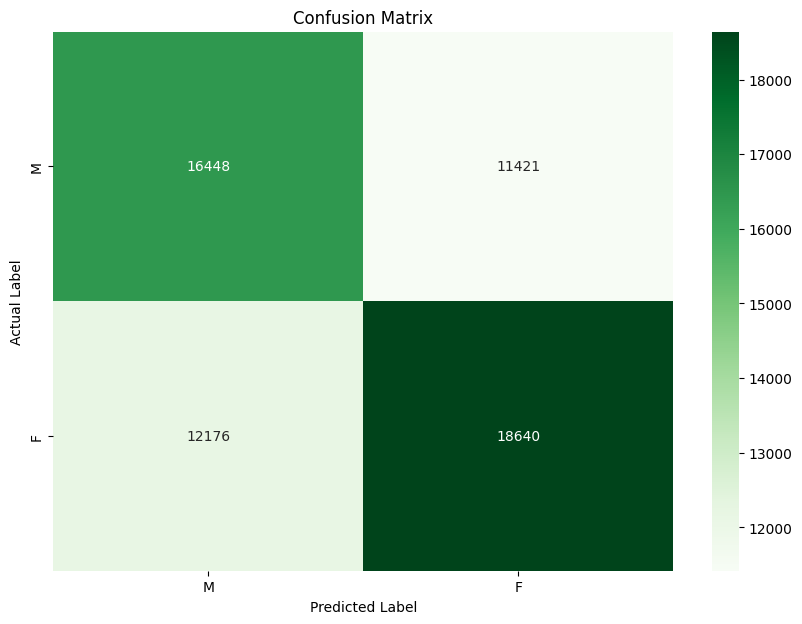

In [575]:
# prompt: display the confusion matrix in a pretty way and name the classes from selected_features

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Assuming y_test and y_pred are defined from your previous code

cm = confusion_matrix(y_test, y_pred)

# Get class names from your selected features (replace with your actual class names)
class_names = list(['M','F'])

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


In [576]:
# prompt: X_train.columns

print(X_train.columns)


Index(['LOC_OF_OCCUR_DESC', 'PREM_TYP_DESC'], dtype='object')


In [585]:
# prompt: create an input_df variable for prediction with all combinations of PD_DESC with all variety of values and LOC_OF_OCCUR_DESC with all variety of values

import itertools

# Get unique values for 'PD_DESC' and 'LOC_OF_OCCUR_DESC'
unique_pd_desc = X['PREM_TYP_DESC'].unique()
unique_loc_of_occur_desc = X['LOC_OF_OCCUR_DESC'].unique()

# Create all possible combinations
combinations = list(itertools.product( unique_loc_of_occur_desc, unique_pd_desc))

# Create a DataFrame with the combinations
input_df = pd.DataFrame(combinations, columns=['LOC_OF_OCCUR_DESC','PREM_TYP_DESC'])

# You might want to apply the same preprocessing steps to input_df as you did to your original data
# For example, label encoding, handling missing values, etc.

# Display the input_df
print(input_df)


     LOC_OF_OCCUR_DESC  PREM_TYP_DESC
0                    2             37
1                    2             63
2                    2             78
3                    2             42
4                    2              0
..                 ...            ...
493                  3             72
494                  3             77
495                  3             75
496                  3             38
497                  3              2

[498 rows x 2 columns]


In [ ]:
# prompt: create an input_df variable for prediction with PD_DESC with all variety

# Create a DataFrame with all unique values from PD_DESC
#unique_pd_desc = filtered_df['LOC_OF_OCCUR_DESC'].unique()
#input_df = pd.DataFrame({'LOC_OF_OCCUR_DESC': unique_pd_desc})


In [595]:
# prompt: predict for each row in input_df, display as dataframe

# Make predictions using the trained model
predictions = mlp.predict(input_df)

# Create a new DataFrame with predictions
prediction_df = input_df.copy()
prediction_df['Predicted_VIC_SEX'] = predictions

# Map predicted values to labels
prediction_df['Predicted_VIC_SEX'] = prediction_df['Predicted_VIC_SEX'].map({1: 'M', 2: 'F'})

# Display the DataFrame with predictions
display(prediction_df)


,LOC_OF_OCCUR_DESC,PREM_TYP_DESC,Predicted_VIC_SEX
0,2,37,M
1,2,63,F
2,2,78,F
3,2,42,M
4,2,0,F
...,...,...,...
493,3,72,M
494,3,77,F
495,3,75,M
496,3,38,M


In [596]:
# prompt: decode values for prediction_df encoded with labelencoder

# Assuming you have the prediction_df DataFrame and the label_encoder object used for encoding.
#print(prediction_df.columns)
# Create a dictionary to store the reverse mapping for each column
columns_to_encode = ['LOC_OF_OCCUR_DESC','PREM_TYP_DESC']
reverse_mapping_dict = {}
for column in columns_to_encode:
  le = LabelEncoder()
  le.fit(before_labeling[column])  # Fit the label encoder on the original DataFrame column
  reverse_mapping_dict[column] = dict(zip(le.transform(le.classes_), le.classes_))

print(reverse_mapping_dict)

# Decode the encoded columns in prediction_df
for column in columns_to_encode:
  if column in prediction_df.columns:  # Check if the column exists in prediction_df
    prediction_df[column] = prediction_df[column].map(reverse_mapping_dict.get(column, lambda x: x))  # Map using the reverse mapping

# Display the decoded prediction_df
display(prediction_df)


{'LOC_OF_OCCUR_DESC': {0: 'FRONT OF', 1: 'INSIDE', 2: 'NOT SPECIFIED', 3: 'OPPOSITE OF', 4: 'OUTSIDE', 5: 'REAR OF'}, 'PREM_TYP_DESC': {0: 'ABANDONED BUILDING', 1: 'AIRPORT TERMINAL', 2: 'ATM', 3: 'BANK', 4: 'BAR/NIGHT CLUB', 5: 'BEAUTY & NAIL SALON', 6: 'BOOK/CARD', 7: 'BRIDGE', 8: 'BUS (NYC TRANSIT)', 9: 'BUS (OTHER)', 10: 'BUS STOP', 11: 'BUS TERMINAL', 12: 'CANDY STORE', 13: 'CEMETERY', 14: 'CHAIN STORE', 15: 'CHECK CASHING BUSINESS', 16: 'CHURCH', 17: 'CLOTHING/BOUTIQUE', 18: 'COLLEGE/UNIVERSITY', 19: 'COMMERCIAL BUILDING', 20: 'CONSTRUCTION SITE', 21: 'DAYCARE FACILITY', 22: 'DEPARTMENT STORE', 23: 'DOCTOR/DENTIST OFFICE', 24: 'DRUG STORE', 25: 'DRY CLEANER/LAUNDRY', 26: 'FACTORY/WAREHOUSE', 27: 'FAST FOOD', 28: 'FERRY/FERRY TERMINAL', 29: 'FOOD SUPERMARKET', 30: 'GAS STATION', 31: 'GROCERY/BODEGA', 32: 'GYM/FITNESS FACILITY', 33: 'HIGHWAY/PARKWAY', 34: 'HOMELESS SHELTER', 35: 'HOSPITAL', 36: 'HOTEL/MOTEL', 37: 'JEWELRY', 38: 'LIQUOR STORE', 39: 'LOAN COMPANY', 40: 'MAILBOX INSID

,LOC_OF_OCCUR_DESC,PREM_TYP_DESC,Predicted_VIC_SEX
0,NOT SPECIFIED,JEWELRY,M
1,NOT SPECIFIED,RESIDENCE-HOUSE,F
2,NOT SPECIFIED,TRANSIT - NYC SUBWAY,F
3,NOT SPECIFIED,MARINA/PIER,M
4,NOT SPECIFIED,ABANDONED BUILDING,F
...,...,...,...
493,OPPOSITE OF,SYNAGOGUE,M
494,OPPOSITE OF,TRAMWAY,F
495,OPPOSITE OF,TAXI/LIVERY (UNLICENSED),M
496,OPPOSITE OF,LIQUOR STORE,M


In [597]:
# prompt: sort female first and convert into an excel sheet

# Sort the prediction_df DataFrame by 'Predicted_VIC_SEX' with females first
prediction_df_sorted = prediction_df.sort_values('Predicted_VIC_SEX', ascending=True)

# Convert the sorted DataFrame to an Excel sheet
prediction_df_sorted.to_excel('prediction_with_vic_sex_sorted.xlsx', index=False)

# Download the Excel file
#from google.colab import files
files.download('prediction_with_vic_sex_sorted.xlsx')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>